#### Prompt Chaining
Prompt chaining is a technique in natural language processing where multiple prompts are sequenced together to guide a model through a complex task or reasoning process. Instead of relying on a single prompt to achieve a desired outcome, prompt chaining breaks the task into smaller, manageable steps, with each step building on the previous one. This approach can improve accuracy, coherence, and control when working with large language models.
LangGraph, is a framework designed to facilitate structured interactions with language models, making it an excellent tool for implementing prompt chaining. It allows you to define a graph of nodes (representing individual prompts or tasks) and edges (representing the flow of information between them). This structure enables dynamic, multi-step conversations or workflows, where the output of one node can feed into the input of the next.

#### How Prompt Chaining Works with LangGraph
1. Define the Task: Start by breaking down the problem into smaller sub-tasks. For example, if you want to generate a detailed report, you might split it into steps like "gather data," "analyze data," and "write summary."

2. Create Nodes: Each sub-task becomes a node in the LangGraph structure. A node could be a prompt that instructs the model to perform a specific action, such as "List key facts about X" or "Summarize the following text."

3. Establish Edges: Edges define the sequence and dependencies between nodes. For instance, the output of the "gather data" node flows into the "analyze data" node, ensuring the model has the necessary context to proceed.

4. Execute the Graph: LangGraph processes the nodes in order, passing information along the edges. The model generates responses step-by-step, refining the output as it progresses through the chain.

5. Iterate if Needed: LangGraph supports conditional logic and loops, so you can revisit earlier nodes or adjust the flow based on intermediate results.

![image.png](attachment:image.png)

In [1]:
import os
from dotenv import load_dotenv

from langchain_groq import ChatGroq

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

llm=ChatGroq(model="llama-3.1-8b-instant")

result=llm.invoke("How are you?")

result

d:\2026-courses\agenticai\langraph\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


AIMessage(content="I'm functioning properly, thanks for asking. I don't have feelings or emotions in the way humans do, but I'm ready to provide information and assist with tasks to the best of my abilities. How can I help you today?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 48, 'prompt_tokens': 39, 'total_tokens': 87, 'completion_time': 0.059378292, 'completion_tokens_details': None, 'prompt_time': 0.002415237, 'prompt_tokens_details': None, 'queue_time': 0.018278592, 'total_time': 0.061793529}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_6a1eabf260', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e2a36-4c45-7bb1-bf7d-d187dbbc8701-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 39, 'output_tokens': 48, 'total_tokens': 87})

In [2]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image ,display

## Graph State
class State(TypedDict):
    topic:str
    story:str
    improved_story:str
    final_story:str

## Nodes
def generate_story(state:State):
    msg=llm.invoke(f"Write a one sentence story premise about {state["topic"]}")
    return {"story":msg.content}

def check_conflict(state:State):
    if "?" in state["story"] or "!" in state["story"]:
        return "Fail"
    return "Pass"

def improved_story(state:State):
    msg=llm.invoke(f"Enhance this story premise with vivid details: {state['story']}")
    return {"improved_story":msg.content}

def polish_story(state:State):
    msg=llm.invoke(f"Add an unexpected twist to this story premise: {state['improved_story']}")
    return {"final_story":msg.content}

d:\2026-courses\agenticai\langraph\Lib\site-packages\langgraph\cache\base\__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


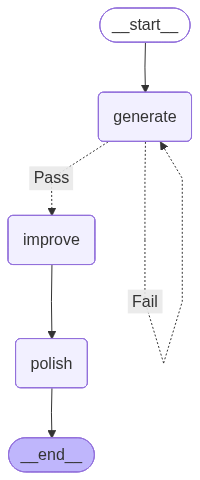

In [3]:
#Build the graph
graph=StateGraph(State)
graph.add_node("generate",generate_story)
graph.add_node("improve", improved_story)
graph.add_node("polish", polish_story)

## Define the edges
graph.add_edge(START,"generate")
graph.add_conditional_edges("generate",check_conflict,{"Pass":"improve","Fail":"generate"})
graph.add_edge("improve","polish")
graph.add_edge("polish",END)

# Compile the graph
compiled_graph = graph.compile()

# Visualize the graph (for Jupyter notebook)
graph_image = compiled_graph.get_graph().draw_mermaid_png()
display(Image(graph_image))

In [5]:
state= {"topic":"how we build startup"}

result = compiled_graph.invoke(state)
result

{'topic': 'how we build startup',
 'story': 'Against the backdrop of a rapidly changing tech landscape, a small group of innovators band together to launch a revolutionary new startup, driven by a shared vision to disrupt the status quo and create a more sustainable future.',
 'improved_story': 'In the heart of Silicon Valley, where the air is thick with the scent of freshly brewed coffee and the sound of startup pitches fills the air, a small group of visionaries converges at an unassuming warehouse nestled between a vintage electronics shop and a sleek, modern co-working space. The sign above the door reads "EchoLab" in bold, neon letters, a beacon calling out to those who dare to challenge the conventional.\n\nInside, the space is a flurry of activity, with makeshift workstations crafted from reclaimed wood and salvaged machinery. The air is electric with the buzz of creativity, as the team of innovators – each with their unique expertise and passion – gather around a large, wooden 

In [6]:
print("Improved Story")
print(result["improved_story"])
print("Polished Story")
print(result["final_story"])

Improved Story
In the heart of Silicon Valley, where the air is thick with the scent of freshly brewed coffee and the sound of startup pitches fills the air, a small group of visionaries converges at an unassuming warehouse nestled between a vintage electronics shop and a sleek, modern co-working space. The sign above the door reads "EchoLab" in bold, neon letters, a beacon calling out to those who dare to challenge the conventional.

Inside, the space is a flurry of activity, with makeshift workstations crafted from reclaimed wood and salvaged machinery. The air is electric with the buzz of creativity, as the team of innovators – each with their unique expertise and passion – gather around a large, wooden table. The room is dominated by a colossal, whiteboard that sprawls across an entire wall, its surface a maze of scribbled notes, diagrams, and equations that seem to dance across the space.

The team's leader, Maya, a fiery entrepreneur with a penchant for disrupting the status quo,

Benefits of Prompt Chaining with LangGraph
- Improved Context Management: By breaking tasks into smaller prompts, the model can focus on one aspect at a time, reducing the risk of losing context in long inputs.

- Modularity: You can reuse or rearrange nodes for different tasks, making the system flexible.

- Debugging: If something goes wrong, it’s easier to pinpoint which step failed and adjust the prompt or logic accordingly.

- Complex Reasoning: Chaining prompts allows the model to "think" step-by-step, mimicking human problem-solving more effectively.